In [ ]:
# Final Year Project - Deepfake Detection Using Vision Transoformers

################################### IMPORTS ###################################
import torch # using PyTorch
import pandas as pd
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt
import torchvision
from torchvision import transforms # for data augmentation
from torchvision.transforms import v2 # also for augmentation
from torch.utils.data import DataLoader, Dataset
from PIL import Image
from IPython.display import Image
from torchvision import datasets
import pandas as pd
from transformers import AutoImageProcessor
from torch import nn
from torch.nn import Module, ModuleList
import math
# for training
import time
from transformers import TrainingArguments
from transformers import Trainer as Trainer1 #helps avoid confusion between methods 1 and 2
import time #for measuring duration of training methods
from sklearn.metrics import accuracy_score #method 1
from google.colab import drive # for CUDA
drive.mount('/content/drive', force_remount=True)
import evaluate


Mounted at /content/drive


In [ ]:
################################ CONFIGURATION #################################

config = {
    "image_size": 72, #input image size #32, 72, 224
    "patch_size": 6, # size of patches image is divided into #4, 6, 16
    "dim": 64, #dimension of transformer model# 48, 768, 896
    "nr_channels": 3, # nr of channels # 3?
    "nr_layers": 4, #4 , 8, 12 , 14 // #4 for small run
    "nr_heads": 4, #nr of attention heads # 4, 12, 14
    "nr_classes": 2, # real or fake
    "dropout": 0, # 0, 0.1 // #0 for small run
    "r_mlp": 4, # 4?
}

################################ TRAINING ARGS #################################

train_args = {
    "learning_rate": 0.001, # 0.0001, 0.0003, 0.001
    "weight_decay": 0.0001, # 0.0001, 0.0003, 0.02, 0.05
    "batch_size":  16, #32, 64, 120, 256 //  #16 for small run
    "epochs" : 5, # 1, 4, 50, 80, 200 // #3 for small run
    "num_workers": 2, #2 cores from colab
    "pin_memory": True
}

In [ ]:
################################## DATA PATHS ##################################
base_path = "/content/drive/My Drive/Colab Notebooks/FinalProject/Dataset"

#train, test, val data paths # # ~ 190.3k otal
train_path = base_path + "/Train" #~140k (70k real, 70k fake)
val_path = base_path + "/Validation" #~39.4k (~19700 real, -//- fake)
test_path = base_path + "/Test" #~10.9k (~5450 real, -//- fake)

############################## DATA AUGMENTATION ###############################

# https://docs.pytorch.org/vision/0.22/transforms.html
# recommended by pytorch for Image Classification
# additions from https://medium.com/@BurtMcGurt/a-practical-guide-to-data-augmentation-in-pytorch-with-examples-and-visualizations-761ad5c2a903
# https://github.com/Deadly-Finisher/-Deep-Fake-Image-Detection-using-PyTorch/blob/main/Deep_Fake.ipynb

train_transforms = v2.Compose([
    v2.ToImage(), # needed only if PIL image
    v2.Resize((config["image_size"], config["image_size"])),
    v2.RandomHorizontalFlip(p=0.5),
    v2.RandomRotation(degrees=10),
    v2.ColorJitter(brightness=0.3, contrast=0.3, saturation=0.3),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

val_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((config["image_size"], config["image_size"])),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])

test_transforms = v2.Compose([
    v2.ToImage(),
    v2.Resize((config["image_size"], config["image_size"])),
    v2.ToDtype(torch.float32, scale=True),
    v2.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
])


################################# LOADING DATA #################################
# https://github.com/Deadly-Finisher/-Deep-Fake-Image-Detection-using-PyTorch/blob/main/Deep_Fake.ipynb

# Load data
train_data = datasets.ImageFolder(train_path, train_transforms)
val_data = datasets.ImageFolder(val_path, val_transforms)
test_data = datasets.ImageFolder(test_path, test_transforms)

dataloaders = {
    "train": DataLoader(train_data, batch_size=train_args["batch_size"], shuffle=True),
    "val": DataLoader(val_data, batch_size=train_args["batch_size"], shuffle=False),
    "test": DataLoader(test_data, batch_size=train_args["batch_size"], shuffle=False)
}

dataset_sizes = {
    "train": len(train_data),
    "val": len(val_data),
    "test": len(test_data)
}
class_names = train_data.classes

#pirnting info
print(f"Classes: {class_names}")
print(f"Train dataset size: {dataset_sizes["train"]}")
print(f"Validation dataset size: {dataset_sizes["val"]}")
print(f"Test dataset size: {dataset_sizes["test"]}")

Classes: ['Fake', 'Real']
Train dataset size: 140002
Validation dataset size: 39428
Test dataset size: 10905


In [ ]:
################################## ViT MODEL ###################################

# patch embedding
class PatchEmbeddings(Module):
    #converting images into patches

    def __init__(self, config):
        super().__init__()
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.emb_dim = config["dim"]
        self.nr_channels = config["nr_channels"]

        self.nr_patches = (self.image_size // self.patch_size) ** 2

        self.project = nn.Conv2d(self.nr_channels, self.emb_dim, kernel_size=self.patch_size, stride=self.patch_size)


    def forward(self, x):
        #batch size, channels, img height, img width > b, emb_dim, patch col, patch row
        x = self.project(x)

        # b, emb_dim, patch col, patch row > b, emb_dim, nr_patches
        x = x.flatten(2)

        #b, dim, patch > b, nr_patches, emb_dim
        x = x.transpose(1,2)

        return x


#positional encoding and class token
class PositionalEmbeddings(Module):
    def __init__(self, config):
        super().__init__()
        self.patch_embeddings = PatchEmbeddings(config)
        nr_patches = (config["image_size"] // config["patch_size"]) ** 2

        # creating classification token
        self.cls_token = nn.Parameter(torch.randn(1, 1, config["dim"]))

        # position emb for the csl token and patches
        self.position_emb = nn.Parameter(torch.randn(1, nr_patches + 1, config["dim"]));

    def forward(self, x):
        # x = self.position_emb(x)
        B = x.size(0)
        x = self.patch_embeddings(x)
        # getting batch size, nr patches and dim
        # b, n, _ = x.shape

        # expanding tokens
        #cls_tokens = self.cls_token.expand(b, -1, -1)
        #tokens = self.cls_token.expand(x.size()[0], -1, -1) # only expanding batch dim, nothing else
        tokens = self.cls_token.expand(B, -1, -1)
        # concatenate token to start of patches
        x = torch.cat((tokens, x), dim = 1)

        # adding positional encoding to embeddins before being outputted
        x = x + self.position_emb
        return x

#single attention head
class Attention(Module):
    #global relationships between patches
    #dependency modelling and spatial context

    def __init__(self, config, head_size):
        super().__init__()
        self.head_size = head_size
        self.dim = config["dim"]
        # inner_dim = self.dim * self.nr_heads
        self.dropout = nn.Dropout(config["dropout"]) #dropout used to prevent overfitting

        self.key = nn.Linear(self.dim, self.head_size)
        self.val = nn.Linear(self.dim, self.head_size)
        self.query = nn.Linear(self.dim, self.head_size)

        #self.to_qkv = nn.Linear(self.dim, inner_dim * 3) # into kets, vals and queries

    def forward(self, x):
        #qkv = self.to_qkv(x).chunk(3, dim = -1)
        #batch_size, nr_patches, inner_dim TO nr_heads, nr_patches, dim_head
        #query, key, val = map(lambda t: rearrange(t), qkv)
        key = self.key(x)
        val = self.val(x)
        query = self.query(x)

        # score = how similar the patch is to other pathces
        # probs = scores but changed to weights
        # output = final result of each head, basically a weighted average of info

        attn_scores = (torch.matmul(query, key.transpose(-1,-2))) / math.sqrt(self.head_size)
        attn_probs = nn.functional.softmax(attn_scores, dim = -1)
        attn_probs = self.dropout(attn_probs)
        output = torch.matmul(attn_probs, val)
        return (output, attn_probs)

class MultiHeadAttention(Module):
    # parallel attention heads
    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]
        self.nr_heads = config["nr_heads"]
        self.head_size = self.dim // self.nr_heads
        self.heads = nn.ModuleList([Attention(config, self.head_size) for _ in range(self.nr_heads)])

        self.to_out = nn.Linear(self.dim, self.dim)

    def forward(self, x):
        out = torch.cat([head(x)[0] for head in self.heads], dim = -1) # 0 gives output, 1 gives probs
        output = self.to_out(out)
        return output


# Multilayer Perceptron / Feed forward Network
class MLP(Module):
    #intorduces non-linearity and for learning complex features
    def __init__(self, config):
        super().__init__()
        self.dim = config["dim"]
        self.dropout = config["dropout"]
        self.r_mlp = config["r_mlp"]
        hidden_dim = self.dim * self.r_mlp
        self.mlp = nn.Sequential(
            nn.Linear(self.dim, hidden_dim),
            nn.GELU(),
            nn.Dropout(self.dropout),
            nn.Linear(hidden_dim, self.dim),
            nn.Dropout(self.dropout)
        )


    def forward(self,x):
        output= self.mlp(x)
        return output


# transofmrer encoder blocks (self attention and Multilayer Perceptron (mlp))
class Encoder(Module):
    # transformer encoder module:
    #layer normalisation
    # multi-head attention
    # residual connections
    # multi layer perception

    def __init__(self, config):
        super().__init__()
        # self.nr_heads = config["nr_heads"]
        self.dim = config["dim"]
        # self.r_mlp = config["r_mlp"]
        # self.dropout = nn.Dropout(config["dropout"])
        #hidden_dim = self.dim * self.r_mlp

        #layer normalisation
        self.norm = nn.LayerNorm(self.dim)
        # multi-head attention
        self.mha = MultiHeadAttention(config)
        # multi layer perception
        self.mlp = MLP(config)
        #nn.Sequential(
        #    nn.Linear(self.dim, hidden_dim),
        #    nn.GELU(), # or ReLU ???
        #    nn.Linear(hidden_dim, self.dim)
        #)
        #self.layers = nn.ModuleList([])


    def forward(self, x):
        x = x + self.mha(self.norm(x)) # after sublayer 1
        output = x + self.mlp(self.norm(x)) #after sublayer 2
        return output

#classification head
class ViTForClassification(Module):

        # self.depth = 0; # how many transformer layers
        # self.batch_size = 0;
        # self.emb_dropout = 0; # dropout rate for embedding

    #def __init__(self, dim, nr_classes, img_size, patch_size, nr_channels, nr_heads, nr_layers):
    def __init__(self,config):
        super().__init__()

        #self.encoder = Encoder(config)
        #self.classifier = nn.Linear(hidden_size, nr_classes)

        # following config build
        self.dim = config["dim"]
        self.image_size = config["image_size"]
        self.patch_size = config["patch_size"]
        self.nr_heads = config["nr_heads"]
        self.nr_channels = config["nr_channels"]
        self.nr_classes = config["nr_classes"]
        self.dropout = config["dropout"]
        self.loss_fn = nn.CrossEntropyLoss()

        #going through each class
        self.positional_emb = PositionalEmbeddings(config)
        #self.cls_token = nn.Parameter(torch.randn(1,1, self.dim))
        #self.encoders = Encoder(config)
        self.encoders = nn.ModuleList([Encoder(config) for _ in range(config["nr_layers"])])
        self.norm = nn.LayerNorm(self.dim)
        # linear layer to project encoders output to nr of classes
        self.classifier = nn.Linear(self.dim, self.nr_classes)

#https://huggingface.co/docs/transformers/v4.27.0/en/main_classes/trainer
    def forward(self, img, labels=None):
        #now running data through each class
        x = self.positional_emb(img) #positional and patch emb
        for layer in self.encoders:
            x = layer(x)

        x = self.norm(x)
        output = self.classifier(x[:, 0])

        #A7
        loss = None
        if labels is not None: #for training method 1
            loss = self.loss_fn(output, labels)
            return (loss, output)

        return output


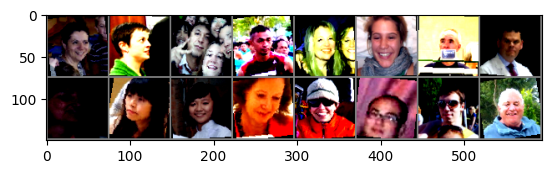

Labels:  Real | Real | Fake | Real | Fake | Fake | Real | Real | Fake | Real | Real | Fake | Real | Real | Real | Fake


In [ ]:
################################### SMALL RUN ##################################

# https://stackoverflow.com/questions/59005242/how-to-get-n-number-of-images-from-torchvision-datasets-imagefolder
# https://docs.pytorch.org/tutorials/beginner/blitz/cifar10_tutorial.html


#dataset = torchvision.datasets.ImageFolder(...)
np.random.seed(42) # for fair comparisons
train_subset = torch.utils.data.Subset(train_data, np.random.choice(len(train_data), 1000, replace=False))
val_subset = torch.utils.data.Subset(val_data, np.random.choice(len(val_data), 250, replace=False))

subsetloaders = {
    "train": DataLoader(train_subset, batch_size=train_args["batch_size"], shuffle=True),
    "val": DataLoader(val_subset, batch_size=train_args["batch_size"], shuffle=False)
}


#https://discuss.huggingface.co/t/error-vars-argument-must-have-dict-attribute-when-trying-to-use-trainer-train/10708
# massive error from method 1 without this
class CLIPDataset(torch.utils.data.Dataset):
    def __init__(self, subset):
        self.subset = subset

    def __getitem__(self, idx):
        image, label = self.subset[idx]
        item = {"img": image}
        item["labels"] = label
        return item

    def __len__(self):
        return len(self.subset)

#specific to method 1
train_subset1 = CLIPDataset(train_subset)
val_subset1 = CLIPDataset(val_subset)

def imshow(img):
    # mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]
    img = img / 2 + 0.5     # unnormalize, tho not fully so colours will be slightly off (but this is insignificant for a small scale run)
    npimg = img.numpy()
    plt.imshow(np.transpose(npimg, (1, 2, 0)))
    plt.show()


# get some random training images
dataiter = iter(dataloaders["train"])
images, labels = next(dataiter)

# show images
imshow(torchvision.utils.make_grid(images[:16])) # showing only 10 images for display
# print labels
#print('Labels: '.join(f'{classes[labels[j]]:5s}' for j in range(4)))
print('Labels: ', ' | '.join(f'{class_names[labels[j]]}' for j in range(16)))

In [ ]:
################################ TRAINING METHODS ################################
# METHOD ONE

#### COMPARING THE METHODS AND PICINGK ONE WITH BEST RESULTS & TIME
torch.manual_seed(42)

device = "cuda"if torch.cuda.is_available() else "cpu"
print(device)

loss_fn = nn.CrossEntropyLoss()

model = ViTForClassification(config)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])


# method one
# https://github.com/arulmickel/deepfakedetect-vit/blob/main/notebooks/DeepfakeDetection_ViT.ipynb
# https://github.com/huggingface/notebooks/blob/main/examples/image_classification.ipynb

def compute_metrics(eval_pred):
    predictions, label_ids = eval_pred
    predicted_labels = predictions.argmax(axis=1)
    acc_score = accuracy_score(label_ids, predicted_labels)
    return {"accuracy": acc_score}

def collate_fn(batch):
    imgs = torch.stack([item["img"] for item in batch])
    labels = torch.tensor([item["labels"] for item in batch])
    return {"img": imgs, "labels": labels}

train_args1 = TrainingArguments(
    output_dir = "/tmp/temporay_results", #A7
    save_strategy="no",#No save is done during training.
    learning_rate= train_args["learning_rate"],
    weight_decay =train_args["weight_decay"],
    per_device_train_batch_size =train_args["batch_size"],
    num_train_epochs =train_args["epochs"],
    eval_strategy="epoch", # Evaluating at the end of each epoch
    logging_strategy = "epoch", #Logging is done at the end of each epoch
)


trainer = Trainer1(
    model = model,
    args = train_args1,
    train_dataset = train_subset1 , # train_data,
    eval_dataset = val_subset1, # val_data,
    compute_metrics = compute_metrics,
    data_collator = collate_fn,
)

# trainer.evaluate()
start_time = time.time() #tracking time
results = trainer.train()
end_time = time.time()
#trainer.log_metrics("train", results.metrics)

#eval_results = trainer.evaluate()
#trainer.log_metrics("eval", eval_results)

# pred_results = trainer.predict(test_data)
# print("Prediction Metrics:", prediction_results.metrics)
#print(f"METHOD 1: Validation loss: {eval_results['eval_loss']:.4f}, Accuracy: {eval_results['eval_accuracy']:.4f}, Duration of training: {end_time-start_time:.2f}s")
print(f"METHOD 1: Duration of training: {end_time-start_time:.2f}s")

#trainer3 = Trainer(model, optimizer, criterion, device)
#trainer3.train_epoch(loader)

cuda


Epoch,Training Loss,Validation Loss,Accuracy
1,0.720068,0.711949,0.532000
2,0.698971,0.669011,0.612000
3,0.622223,0.641705,0.632000
4,0.576619,0.672618,0.624000
5,0.557331,0.672725,0.628000


METHOD 1: Duration of training: 87.23s


In [ ]:
# METHOD TWO

torch.manual_seed(42)

device = "cuda"if torch.cuda.is_available() else "cpu"
print(device)


loss_fn = nn.CrossEntropyLoss()

model = ViTForClassification(config)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])


#method two
#https://github.com/tintn/vision-transformer-from-scratch/blob/main/vision_transformers.ipynb

class Trainer:
    def __init__(self, model, optimizer, loss_fn, device):
        self.model = model.to(device)
        self.optimizer = optimizer
        self.loss_fn = loss_fn
        self.device = device

    def train(self, trainloader, valloader, epochs):

        # Keep track of the losses and accuracies
        train_losses, val_losses, accuracies = [], [], []
        start_time = time.time() #tracking time


        # Train the model
        for epoch in range(epochs): #train_args["epochs"]
            e_start_time = time.time()

            train_loss = self.train_epoch(trainloader)
            accuracy, val_loss = self.evaluate(valloader)

            train_losses.append(train_loss)
            val_losses.append(val_loss)
            accuracies.append(accuracy)

            e_end_time = time.time()

            print(f"METHOD 2: Epoch: {epoch+1},  Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f}, Accuracy: {accuracy*100:.2f}%")
            #if save_model_every_n_epochs > 0 and (i+1) % save_model_every_n_epochs == 0 and i+1 != epochs:
                #print('\tSave checkpoint at epoch', i+1)
                #save_checkpoint(self.exp_name, self.model, i+1)
        # Save the experiment
        #save_experiment(self.exp_name, config, self.model, train_losses, test_losses, accuracies)
        end_time = time.time()
        print(f"Duration of training: {end_time-start_time:.2f}s")



    def train_epoch(self, trainloader):

        self.model.train()
        total_loss = 0
        for batch in trainloader:
            # Move the batch to the device
            batch = [t.to(self.device) for t in batch]
            images, labels = batch
            # Zero the gradients
            self.optimizer.zero_grad()
            # Calculate the loss
            loss = self.loss_fn(self.model(images), labels) #my classification head returns self.classifier(enc[:, 0]) therefore dont need to do self.model(images)[0] like tintn
            # Backpropagate the loss
            loss.backward()
            # Update the model's parameters
            self.optimizer.step()
            total_loss += loss.item() * len(images)
        return total_loss / len(trainloader.dataset)

    # add def evaluate ?

    def evaluate(self, valloader):
        self.model.eval()
        total_loss = 0
        correct = 0
        with torch.no_grad():
            for batch in valloader:
                # Move the batch to the device
                batch = [t.to(self.device) for t in batch]
                images, labels = batch

                # Get predictions
                logits = self.model(images)

                # Calculate the loss
                loss = self.loss_fn(logits, labels)
                total_loss += loss.item() * len(images)

                # Calculate the accuracy
                predictions = torch.argmax(logits, dim=1)
                correct += torch.sum(predictions == labels).item()
        accuracy = correct / len(valloader.dataset)
        avg_loss = total_loss / len(valloader.dataset)
        return accuracy, avg_loss

#trainer = Trainer(model, optimizer, loss_fn, args.exp_name, device=device)
#trainer.train(trainloader, testloader, epochs, save_model_every_n_epochs=save_model_every_n_epochs)

trainer = Trainer(model, optimizer, loss_fn, device)
trainer.train(subsetloaders["train"],subsetloaders["val"], train_args["epochs"])

cuda
METHOD 2: Epoch: 1,  Time: 18.49s, Train loss: 0.7182, Validation loss: 0.6998, Accuracy: 56.00%
METHOD 2: Epoch: 2,  Time: 16.02s, Train loss: 0.7098, Validation loss: 0.6791, Accuracy: 54.80%
METHOD 2: Epoch: 3,  Time: 16.10s, Train loss: 0.6176, Validation loss: 0.6375, Accuracy: 65.60%
METHOD 2: Epoch: 4,  Time: 16.05s, Train loss: 0.5825, Validation loss: 0.6027, Accuracy: 68.00%
METHOD 2: Epoch: 5,  Time: 15.50s, Train loss: 0.5438, Validation loss: 0.6261, Accuracy: 66.40%
Duration of training: 82.17s


In [ ]:
# METHOD THREE

torch.manual_seed(42)

device = "cuda"if torch.cuda.is_available() else "cpu"
print(device)

loss_fn = nn.CrossEntropyLoss()

model = ViTForClassification(config).to(device)

optimizer = torch.optim.AdamW(model.parameters(),
                              lr = train_args["learning_rate"],
                              weight_decay = train_args["weight_decay"])


criterion = nn.CrossEntropyLoss().to(device)



#method three
# https://github.com/pytorch/examples/blob/main/imagenet/main.py
class AverageMeter(object):
    def __init__(self, name):
        self.name = name
        self.reset()

    def reset(self):
        self.val = 0
        self.avg = 0
        self.sum = 0
        self.count = 0

    def update(self, val, n=1):
        self.val = val
        self.sum += val * n
        self.count += n
        self.avg = self.sum / self.count


def accuracy(output, target):
    with torch.no_grad():
        batch_size = target.size(0)
        _, pred = output.topk(1, 1, True, True)
        pred = pred.t()

        correct = pred.eq(target.view(1, -1).expand_as(pred))
        correct_1 = correct[:1].reshape(-1).float().sum(0, keepdim=True)
        res= correct_1.mul_(100.0 / batch_size)
        return res


def train(train_loader, model, criterion, optimizer, device):
    losses = AverageMeter("Loss")

    # switch to train mode
    model.train()

    start = time.time()
    for i, (images, target) in enumerate(train_loader):

        # move data to the same device as model
        images = images.to(device, non_blocking=True)
        target = target.to(device, non_blocking=True)

        # compute output
        output = model(images)
        loss = criterion(output, target)

        #record loss
        losses.update(loss.item(), images.size(0))

        # compute gradient and do SGD step
        optimizer.zero_grad() #clearing old gradients
        loss.backward() #new gradients
        optimizer.step() #updating weights

    return losses.avg


def validate(valloader, model, criterion, device):
    model.eval()
    losses = AverageMeter("Loss")
    acc = AverageMeter("Accuracy")

    model.eval()

    with torch.no_grad():
        for i, (images, target) in enumerate(valloader):
            images = images.to(device)
            target = target.to(device)

            output = model(images)
            loss = criterion(output, target)

            #calculating accuracy for method comparison
            acc1 = accuracy(output, target).item()

            losses.update(loss.item(), images.size(0))
            acc.update(acc1, images.size(0))

    return losses.avg, acc.avg



#avg loss from https://github.com/aidendorian/Vision-Transformer-for-DeepFake-Detection/blob/master/pre_training.py
start_time = time.time()

for epoch in range(train_args["epochs"]):
    e_start_time = time.time()
    # for small run
    train_loss = train(subsetloaders["train"], model, criterion, optimizer,device)
    val_loss, acc = validate(subsetloaders["val"],model, criterion, device)
    e_end_time = time.time()
    #main runs
    #train_loss = train(dataloaders["train"], model, criterion, optimizer,device)
    #val_loss, acc = validate(dataloaders["val"],model, criterion, device)

    print(f"METHOD 3: Epoch: {epoch+1}, Time: {e_end_time - e_start_time:.2f}s, Train loss: {train_loss:.4f}, Validation loss: {val_loss:.4f},  Accuracy: {acc:.2f}%")

end_time = time.time()
print(f"Duration of training: {end_time - start_time:.2f}s")

cuda
METHOD 3: Epoch: 1, Time: 18.19s, Train loss: 0.7182, Validation loss: 0.6998,  Accuracy: 56.00%
METHOD 3: Epoch: 2, Time: 15.28s, Train loss: 0.7098, Validation loss: 0.6791,  Accuracy: 54.80%
METHOD 3: Epoch: 3, Time: 15.13s, Train loss: 0.6176, Validation loss: 0.6374,  Accuracy: 65.60%
METHOD 3: Epoch: 4, Time: 15.64s, Train loss: 0.5825, Validation loss: 0.6027,  Accuracy: 68.00%
METHOD 3: Epoch: 5, Time: 16.39s, Train loss: 0.5438, Validation loss: 0.6262,  Accuracy: 66.40%
Duration of training: 80.63s


In [ ]:
!pip install evaluate

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 84.1/84.1 kB 3.8 MB/s eta 0:00:00
